In [3]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Data loaded successfully
Data cleaned successfully
Feature engineering completed
Analysis completed


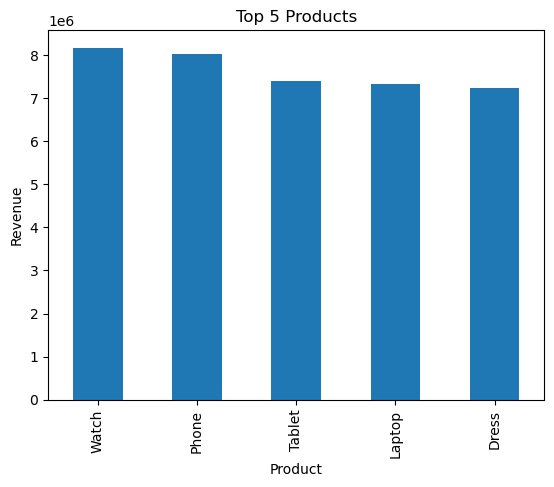

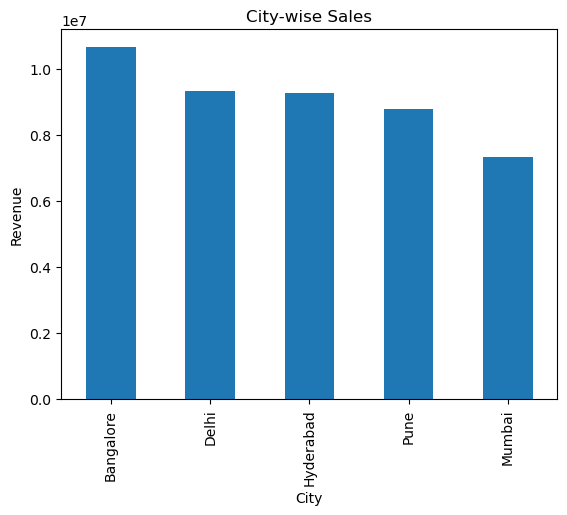

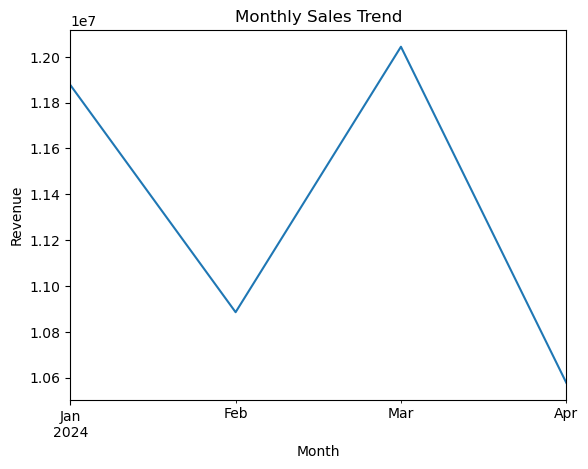

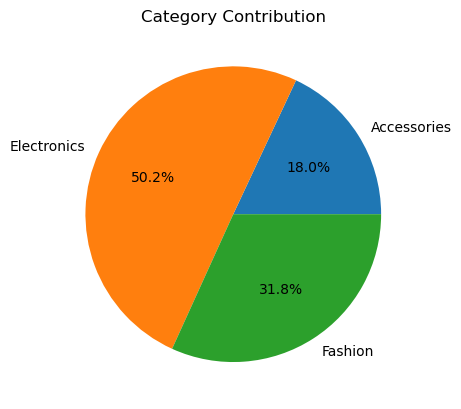

Charts created successfully
Report generated successfully


In [4]:
class RetailAnalytics:
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None
    # 1. Data Loading
    def load_data(self):
        try:
            self.df = pd.read_csv(self.file_path)
            print("Data loaded successfully")
        except FileNotFoundError:
            print("File not found")
        except Exception as e:
            print("Error:", e)
    # 2. Data Cleaning
    def clean_data(self):
        self.df['Customer'] = self.df['Customer'].fillna('Unknown')
        self.df['City'] = self.df['City'].str.strip().str.title()
        self.df['Date'] = pd.to_datetime(self.df['Date'], errors='coerce')
        self.df['Price'] = pd.to_numeric(self.df['Price'], errors='coerce')

        # Remove invalid rows
        self.df = self.df.dropna(subset=['Date', 'Price', 'Quantity'])
        print("Data cleaned successfully")
        
    # 3. Feature Engineering
    def feature_engineering(self):
        self.df['Revenue'] = self.df['Quantity'] * self.df['Price']
        print("Feature engineering completed")
        
    # 4. Data Analysis (EDA)
    def analyze_data(self):
        self.total_revenue = self.df['Revenue'].sum()

        self.top_products = self.df.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(5)

        self.city_sales = self.df.groupby('City')['Revenue'].sum().sort_values(ascending=False)

        self.df['Month'] = self.df['Date'].dt.to_period('M')
        self.monthly_sales = self.df.groupby('Month')['Revenue'].sum()

        self.category_perf = self.df.groupby('Category')['Revenue'].sum()

        #Collections
        self.customer_spending = self.df.groupby('Customer')['Revenue'].sum().to_dict()
        self.unique_cities = set(self.df['City'])

        self.top_customers = self.df.groupby('Customer')['Revenue'].sum().sort_values(ascending=False).head(5)
        print("Analysis completed")
        
        # 5. Data Visualization
    def create_charts(self):
        # Top 5 Products
        plt.figure()
        self.top_products.plot(kind='bar')
        plt.title('Top 5 Products')
        plt.xlabel('Product')
        plt.ylabel('Revenue')
        plt.savefig('top_products.png')
        plt.show()
        plt.close()

        # City-wise Sales
        plt.figure()
        self.city_sales.head(10).plot(kind='bar')
        plt.title('City-wise Sales')
        plt.xlabel('City')
        plt.ylabel('Revenue')
        plt.savefig('city_sales.png')
        plt.show()
        plt.close()

        # Monthly Sales Trend
        plt.figure()
        self.monthly_sales.plot(kind='line')
        plt.title('Monthly Sales Trend')
        plt.xlabel('Month')
        plt.ylabel('Revenue')
        plt.savefig('monthly_trend.png')
        plt.show()
        plt.close()

        # Category Contribution
        plt.figure()
        self.category_perf.plot(kind='pie', autopct='%1.1f%%')
        plt.title('Category Contribution')
        plt.ylabel('')
        plt.savefig('category_pie.png')
        plt.show()
        plt.close()

        print("Charts created successfully")
        
        # 6. Report Generation
    def generate_report(self):
        top_product = self.top_products.idxmax()
        top_city = self.city_sales.idxmax()
        top_category = self.category_perf.idxmax()

        report = f"""
Total Revenue: {self.total_revenue}

Top Product: {top_product}
Top City: {top_city}
Top Category: {top_category}

Top 5 Customers:
{self.top_customers}

Unique Cities:
{list(self.unique_cities)}
"""

        with open('final_report.txt', 'w') as f:
            f.write(report)

        print("Report generated successfully")




if __name__ == "__main__":
    file_path = "raw_retail_dataset_500.csv"
    project = RetailAnalytics(file_path)
    project.load_data()
    project.clean_data()
    project.feature_engineering()
    project.analyze_data()
    project.create_charts()
    project.generate_report()

# Dataset loading

In [5]:
project.df

,OrderID,Date,Customer,City,Product,Category,Quantity,Price
0,1,2024-03-22,NaN,Delhi,Phone,Electronics,1,45348
1,2,2024-03-10,Riya,mumbai,Phone,Electronics,2,34118
2,3,2024-03-12,Sara,Hyderabad,Shoes,Fashion,5,19231
3,4,2024-01-01,John,Delhi,Phone,Electronics,3,7698
4,5,2024-01-13,Neha,Hyderabad,Laptop,Electronics,4,36142
...,...,...,...,...,...,...,...,...
495,496,2024-03-20,Pooja,Delhi,Dress,Fashion,5,13875
496,497,2024-01-25,Raj,Mumbai,Phone,Electronics,5,8821
497,498,2024-02-24,Raj,Pune,Tablet,Electronics,1,22663
498,499,2024-04-29,NaN,Delhi,Watch,Accessories,5,56256


In [6]:
project.df.head()

,OrderID,Date,Customer,City,Product,Category,Quantity,Price
0,1,2024-03-22,NaN,Delhi,Phone,Electronics,1,45348
1,2,2024-03-10,Riya,mumbai,Phone,Electronics,2,34118
2,3,2024-03-12,Sara,Hyderabad,Shoes,Fashion,5,19231
3,4,2024-01-01,John,Delhi,Phone,Electronics,3,7698
4,5,2024-01-13,Neha,Hyderabad,Laptop,Electronics,4,36142


In [7]:
project.df.tail()

,OrderID,Date,Customer,City,Product,Category,Quantity,Price
495,496,2024-03-20,Pooja,Delhi,Dress,Fashion,5,13875
496,497,2024-01-25,Raj,Mumbai,Phone,Electronics,5,8821
497,498,2024-02-24,Raj,Pune,Tablet,Electronics,1,22663
498,499,2024-04-29,NaN,Delhi,Watch,Accessories,5,56256
499,500,2024-03-03,Neha,Delhi,Phone,Electronics,5,5468


In [8]:
project.df.isnull().sum()

OrderID      0
Date         0
Customer    26
City         0
Product      0
Category     0
Quantity     0
Price        0
dtype: int64

In [9]:
project.df.columns

Index(['OrderID', 'Date', 'Customer', 'City', 'Product', 'Category',
       'Quantity', 'Price'],
      dtype='object')

In [10]:
project.df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   OrderID   500 non-null    int64 
 1   Date      500 non-null    object
 2   Customer  474 non-null    object
 3   City      500 non-null    object
 4   Product   500 non-null    object
 5   Category  500 non-null    object
 6   Quantity  500 non-null    int64 
 7   Price     500 non-null    int64 
dtypes: int64(3), object(5)
memory usage: 31.4+ KB


# after cleaning the data

In [12]:
project.df

,OrderID,Date,Customer,City,Product,Category,Quantity,Price
0,1,2024-03-22,Unknown,Delhi,Phone,Electronics,1,45348
1,2,2024-03-10,Riya,Mumbai,Phone,Electronics,2,34118
2,3,2024-03-12,Sara,Hyderabad,Shoes,Fashion,5,19231
3,4,2024-01-01,John,Delhi,Phone,Electronics,3,7698
4,5,2024-01-13,Neha,Hyderabad,Laptop,Electronics,4,36142
...,...,...,...,...,...,...,...,...
495,496,2024-03-20,Pooja,Delhi,Dress,Fashion,5,13875
496,497,2024-01-25,Raj,Mumbai,Phone,Electronics,5,8821
497,498,2024-02-24,Raj,Pune,Tablet,Electronics,1,22663
498,499,2024-04-29,Unknown,Delhi,Watch,Accessories,5,56256


In [13]:
project.df.isnull().sum()

OrderID     0
Date        0
Customer    0
City        0
Product     0
Category    0
Quantity    0
Price       0
dtype: int64

In [15]:
project.df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   OrderID   500 non-null    int64         
 1   Date      500 non-null    datetime64[ns]
 2   Customer  500 non-null    object        
 3   City      500 non-null    object        
 4   Product   500 non-null    object        
 5   Category  500 non-null    object        
 6   Quantity  500 non-null    int64         
 7   Price     500 non-null    int64         
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 31.4+ KB


# Feature Engineering

In [17]:
project.df

,OrderID,Date,Customer,City,Product,Category,Quantity,Price,Revenue
0,1,2024-03-22,Unknown,Delhi,Phone,Electronics,1,45348,45348
1,2,2024-03-10,Riya,Mumbai,Phone,Electronics,2,34118,68236
2,3,2024-03-12,Sara,Hyderabad,Shoes,Fashion,5,19231,96155
3,4,2024-01-01,John,Delhi,Phone,Electronics,3,7698,23094
4,5,2024-01-13,Neha,Hyderabad,Laptop,Electronics,4,36142,144568
...,...,...,...,...,...,...,...,...,...
495,496,2024-03-20,Pooja,Delhi,Dress,Fashion,5,13875,69375
496,497,2024-01-25,Raj,Mumbai,Phone,Electronics,5,8821,44105
497,498,2024-02-24,Raj,Pune,Tablet,Electronics,1,22663,22663
498,499,2024-04-29,Unknown,Delhi,Watch,Accessories,5,56256,281280


# Data Analysis(EDA)

In [5]:
project.df

,OrderID,Date,Customer,City,Product,Category,Quantity,Price,Revenue,Month
0,1,2024-03-22,Unknown,Delhi,Phone,Electronics,1,45348,45348,2024-03
1,2,2024-03-10,Riya,Mumbai,Phone,Electronics,2,34118,68236,2024-03
2,3,2024-03-12,Sara,Hyderabad,Shoes,Fashion,5,19231,96155,2024-03
3,4,2024-01-01,John,Delhi,Phone,Electronics,3,7698,23094,2024-01
4,5,2024-01-13,Neha,Hyderabad,Laptop,Electronics,4,36142,144568,2024-01
...,...,...,...,...,...,...,...,...,...,...
495,496,2024-03-20,Pooja,Delhi,Dress,Fashion,5,13875,69375,2024-03
496,497,2024-01-25,Raj,Mumbai,Phone,Electronics,5,8821,44105,2024-01
497,498,2024-02-24,Raj,Pune,Tablet,Electronics,1,22663,22663,2024-02
498,499,2024-04-29,Unknown,Delhi,Watch,Accessories,5,56256,281280,2024-04
